In [1]:
!pip uninstall -y transformers
!pip install -q transformers==4.46.3 accelerate timm sentencepiece

Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Smart-TryOn-System

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Smart-TryOn-System


In [3]:
import json
import torch

from Utils.config import *
from Utils.file_utlis import *
from Utils.image_utils import *
from Utils.model_loader import load_florence


In [4]:
processor, model = load_florence()

Loading Florence-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✓ Florence-2 loaded successfully.
Device : cuda
Model  : microsoft/Florence-2-base


In [5]:
pairs = read_csv(PAIRS_MANIFEST)

pairs.head()

,pair_id,person_image,garment_image,source,use,edge_case_notes
0,pair_01,person/person_01.png,garment/garment_01.jpg,provided,official test pair (Q3-Q5),clean baseline pair
1,pair_02,person/person_02.png,garment/garment_02.jpg,provided,official test pair (Q3-Q5),person has hair over left shoulder (Q2 edge case)
2,pair_03,person/person_03.png,garment/garment_03.jpg,provided,official test pair (Q3-Q5),person has hair over left shoulder; garment is...
3,pair_04,NaN,NaN,candidate,candidate-sourced pair (Q3-Q5),NaN
4,pair_05,NaN,NaN,candidate,candidate-sourced pair (Q3-Q5),NaN


In [6]:
sample = pairs.iloc[0]

person_path = DATA_DIR / "test_pairs" / sample["person_image"]

garment_path = DATA_DIR / "test_pairs" / sample["garment_image"]

print(person_path)

print(garment_path)

/content/drive/MyDrive/Smart-TryOn-System/Data/test_pairs/person/person_01.png
/content/drive/MyDrive/Smart-TryOn-System/Data/test_pairs/garment/garment_01.jpg


In [7]:
person_image = load_image(person_path)
garment_image = load_image(garment_path)

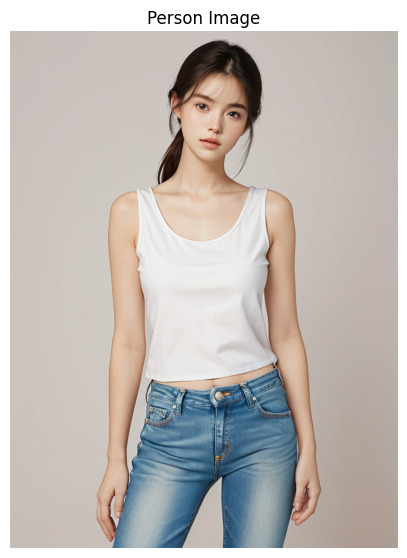

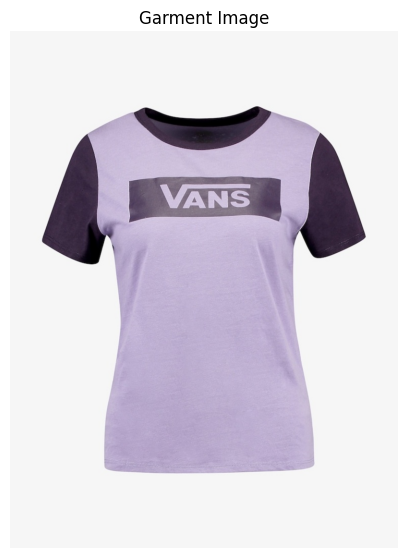

In [8]:
show_image(person_image, "Person Image")
show_image(garment_image, "Garment Image")

In [21]:
garment_prompt = "<DETAILED_CAPTION>"

person_prompt = "<DETAILED_CAPTION>"

In [23]:
from Utils.config import DEVICE, DTYPE, MAX_NEW_TOKENS, NUM_BEAMS

def run_florence(image, prompt):

    inputs = processor(
        text=prompt,
        images=image,
        return_tensors="pt"
    )

    # Move everything to the selected device
    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    # Match the model dtype
    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(dtype=DTYPE)

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS,
        do_sample=False
    )

    generated_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return generated_text.strip()

In [24]:
garment_response = run_florence(
    garment_image,
    garment_prompt
)

person_response = run_florence(
    person_image,
    person_prompt
)

In [25]:
print("Garment Response\n")

print(garment_response)

print()

print("Person Response\n")

print(person_response)

Garment Response

The image shows a purple and black Vans t-shirt with the iconic Vans logo on the front. The background is a crisp white, highlighting the vibrant colors of the shirt.

Person Response

The image shows a model wearing a white tank top and blue jeans, standing against a cream-colored background. The tank top has a scoop neckline and thin straps, and the jeans are a light blue color.


In [34]:
def extract_garment_attributes(caption):

    text = caption.lower()

    result = {
        "garment_type": "Unknown",
        "sleeve_length": "Unknown",
        "neckline": "Unknown",
        "primary_color": "Unknown",
        "pattern": "Plain"
    }

    # ---------- Garment Type ----------
    if "t-shirt" in text or "tshirt" in text:
        result["garment_type"] = "T-Shirt"

    elif "shirt" in text:
        result["garment_type"] = "Shirt"

    elif "tank top" in text:
        result["garment_type"] = "Tank Top"

    elif "hoodie" in text:
        result["garment_type"] = "Hoodie"

    elif "jacket" in text:
        result["garment_type"] = "Jacket"

    elif "dress" in text:
        result["garment_type"] = "Dress"

    # ---------- Sleeve ----------

    if "tank top" in text or "thin straps" in text:
        result["sleeve_length"] = "Sleeveless"

    elif "long-sleeved" in text or "long sleeve" in text:
        result["sleeve_length"] = "Long"

    elif "short-sleeved" in text or "short sleeve" in text:
        result["sleeve_length"] = "Short"

    # ---------- Neckline ----------

    if "collar" in text or "collared" in text:
        result["neckline"] = "Collar"

    elif "crew neck" in text:
        result["neckline"] = "Crew Neck"

    elif "round neck" in text:
        result["neckline"] = "Round Neck"

    elif "v-neck" in text:
        result["neckline"] = "V-Neck"

    elif "scoop neckline" in text:
        result["neckline"] = "Scoop Neck"

    # ---------- Color ----------

    colors = [
        "black",
        "white",
        "blue",
        "red",
        "green",
        "yellow",
        "brown",
        "gray",
        "grey",
        "pink",
        "purple",
        "orange",
        "beige",
        "cream",
        "navy"
    ]

    found = []

    for color in colors:
        if color in text:
            found.append(color.title())

    if found:
        result["primary_color"] = ", ".join(found)

    # ---------- Pattern ----------

    if "logo" in text:
        result["pattern"] = "Logo"

    elif "graphic" in text:
        result["pattern"] = "Graphic"

    elif "striped" in text:
        result["pattern"] = "Striped"

    elif "checked" in text:
        result["pattern"] = "Checked"

    elif "floral" in text:
        result["pattern"] = "Floral"

    return result

In [35]:
def extract_person_attributes(caption):

    text = caption.lower()

    pose = "Unknown"

    if "facing the camera" in text:
        pose = "Front-facing"

    elif "front view" in text:
        pose = "Front-facing"

    elif "front-facing" in text:
        pose = "Front-facing"

    elif "standing" in text:
        pose = "Front-facing"

    elif "side" in text:
        pose = "Side"

    elif "sitting" in text or "seated" in text:
        pose = "Seated"

    upper = any(word in text for word in [
        "shirt", "t-shirt", "blouse",
        "hoodie", "jacket", "top",
        "sweater", "coat"
    ])

    lower = any(word in text for word in [
        "pants", "trousers", "jeans",
        "shorts", "skirt"
    ])

    return {
        "pose": pose,
        "upper_body_visible": upper,
        "lower_body_visible": lower
    }

In [39]:
garment_result = extract_garment_attributes(
    garment_response
)

person_result = extract_person_attributes(
    person_response
)

print(garment_result)

print()

print(person_result)

{'garment_type': 'T-Shirt', 'sleeve_length': 'Unknown', 'neckline': 'Unknown', 'primary_color': 'Black, White, Purple', 'pattern': 'Logo'}

{'pose': 'Front-facing', 'upper_body_visible': True, 'lower_body_visible': True}


print(garment_response)
print(person_response)